# BA820 Project M4 – Individual Refinement
This notebook evaluates whether behavioral structure identified in M2 and
integrated in M3 remains stable under methodological refinement. Rather than discovering new clusters, the goal is to validate structural robustness.

**1. Import Packages**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

**2. Load Data**

In [6]:
cats = pd.read_csv("cats_uk.csv")
cats_ref = pd.read_csv("cats_uk_reference 2.csv")

cats.head()

,tag_id,event_id,visible,timestamp,location_long,location_lat,ground_speed,height_above_ellipsoid,algorithm_marked_outlier,manually_marked_outlier,study_name
0,Ares,3395610551,True,2017-06-24T01:03:57Z,-5.113851,50.170315,684,154.67,False,False,Pet Cats United Kingdom
1,Ares,3395610552,True,2017-06-24T01:11:20Z,-5.113851,50.170315,936,154.67,False,False,Pet Cats United Kingdom
2,Ares,3395610553,True,2017-06-24T02:58:16Z,-5.113730,50.169876,2340,81.35,False,False,Pet Cats United Kingdom
3,Ares,3395610554,True,2017-06-24T03:01:26Z,-5.113774,50.169827,0,67.82,False,False,Pet Cats United Kingdom
4,Ares,3395610555,True,2017-06-24T03:51:58Z,-5.114247,50.170139,4896,118.03,False,False,Pet Cats United Kingdom


I reuse the same dataset and analytical unit established in M2 to ensure comparability across milestones.

**3. Rebuild M2 Feature Pipeline**

In [8]:
cats.columns

Index(['tag_id', 'event_id', 'visible', 'timestamp', 'location_long',
       'location_lat', 'ground_speed', 'height_above_ellipsoid',
       'algorithm_marked_outlier', 'manually_marked_outlier', 'study_name'],
      dtype='object')

In [9]:
cats_ref.columns

Index(['tag_id', 'animal_id', 'animal_taxon', 'deploy_on_date',
       'deploy_off_date', 'hunt', 'prey_p_month',
       'animal_reproductive_condition', 'animal_sex', 'hrs_indoors', 'n_cats',
       'food_dry', 'food_wet', 'food_other', 'study_site', 'age_years'],
      dtype='object')

In [10]:
cats_full = cats.merge(
    cats_ref,
    on="tag_id",
    how="left"
)

cats_full.head()

,tag_id,event_id,visible,timestamp,location_long,location_lat,ground_speed,height_above_ellipsoid,algorithm_marked_outlier,manually_marked_outlier,...,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,food_other,study_site,age_years
0,Ares,3395610551,True,2017-06-24T01:03:57Z,-5.113851,50.170315,684,154.67,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
1,Ares,3395610552,True,2017-06-24T01:11:20Z,-5.113851,50.170315,936,154.67,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
2,Ares,3395610553,True,2017-06-24T02:58:16Z,-5.113730,50.169876,2340,81.35,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
3,Ares,3395610554,True,2017-06-24T03:01:26Z,-5.113774,50.169827,0,67.82,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
4,Ares,3395610555,True,2017-06-24T03:51:58Z,-5.114247,50.170139,4896,118.03,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0


In [11]:
cat_level = cats_full.groupby("tag_id").agg({
    "ground_speed": ["mean","std","max"],
    "hrs_indoors": "mean",
    "age_years": "mean",
    "prey_p_month": "mean"
})

cat_level.columns = [
    "speed_mean",
    "speed_std",
    "speed_max",
    "hrs_indoors",
    "age_years",
    "prey_p_month"
]

cat_level = cat_level.dropna()
cat_level.head()

,speed_mean,speed_std,speed_max,hrs_indoors,age_years,prey_p_month
tag_id,,,,,,
Abba-Tag,1603.951807,2149.160017,13968,7.5,3.0,3.0
Alfie-Tag,1931.679144,2413.262206,14652,7.5,3.0,3.0
Amber-Tag,1967.614679,2602.831283,21888,7.5,4.0,3.0
Ares,2285.825243,2636.692508,14328,7.5,3.0,0.0
Athena,2134.188679,2685.603928,19728,7.5,3.0,3.0


**4. Feature Scaling**

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cat_level)

**5. Structural Validation: Testing Cluster Stability**

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in [2,3,4]:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.308
k=3, silhouette=0.350
k=4, silhouette=0.308


To evaluate whether distinct behavioral types exist among cats, we compared clustering solutions across different numbers of clusters, k = 2, 3, 4, using silhouette scores.

The results show moderate separation overall, with the highest silhouette score observed at k = 3, while k = 2 and k = 4 produce slightly lower but comparable scores. The relatively small differences across k values suggest that no single cluster configuration clearly dominates.

This pattern indicates that behavioral variation is not strongly organized into sharply separated categories. Instead, the data appear to reflect gradual differences in activity levels rather than clearly distinct behavioral types. Increasing the number of clusters does not substantially improve structural clarity, and additional clusters mainly subdivide existing variation rather than revealing fundamentally new groups.

These findings are consistent with insights developed in M3, supporting the interpretation that cat movement behavior is better characterized as a continuum or activity gradient rather than multiple stable behavioral profiles.

**6. Visualization**

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

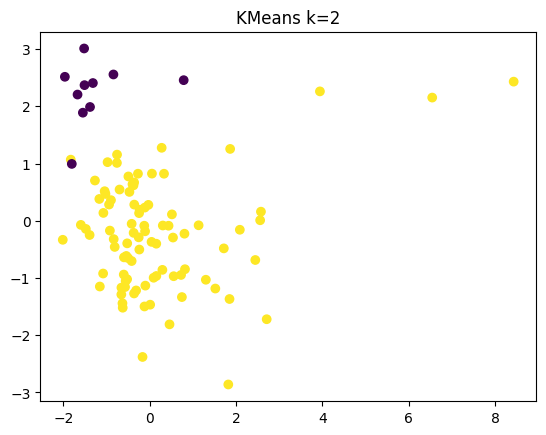

In [16]:
km2 = KMeans(n_clusters=2, random_state=42)
labels2 = km2.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels2)
plt.title("KMeans k=2")
plt.show()

The k=2 solution shows a coarse separation, most cats form a single dense cluster, while a smaller group is separated in the PCA space. This suggests that the dominant structure is broad, such as overall activity intensity, rather than multiple clearly distinct behavioral types. The separation is driven mainly by a minority of cats with more extreme movement patterns.

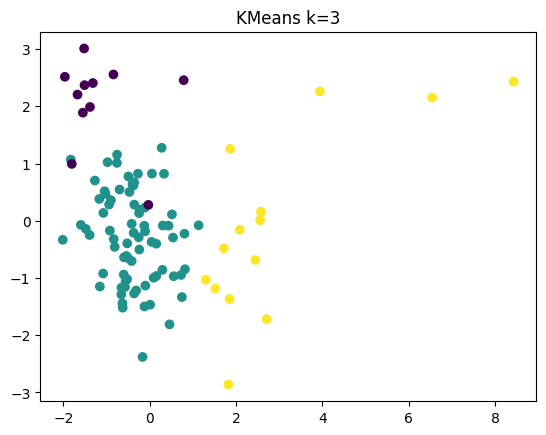

In [17]:
km3 = KMeans(n_clusters=3, random_state=42)
labels3 = km3.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels3)
plt.title("KMeans k=3")
plt.show()

When increasing to k=3, the model primarily subdivides the main cluster into two overlapping groups and isolates a small set of extreme observations. Cluster boundaries remain fuzzy, indicating that the additional cluster does not reveal a fundamentally new behavioral category but rather partitions a continuous gradient. This visual pattern aligns with the silhouette comparison, k=3 slightly improves fit, but the overall structure still lacks sharply separated types.

**7. Structural Validation Through Multiple Views**

Cluster stability was evaluated by comparing solutions across different numbers of clusters, k = 2, 3, 4, using silhouette scores and PCA visualization.

Although k = 3 yields a slightly higher silhouette score, differences across k values remain small. Visual inspection shows substantial overlap between clusters under all configurations.

Rather than revealing clearly distinct behavioral categories, increasing k primarily subdivides existing variation. The clustering structure therefore appears relatively weak and sensitive to modeling choices, suggesting that cat movement behavior is better interpreted as a continuum rather than stable discrete types.

**8. Integrated Findings**

Across multiple analytical steps—including feature reconstruction, clustering comparison, silhouette evaluation, and PCA visualization—the results consistently suggest that cat movement behavior does not organize into clearly separated behavioral types.

Although k = 3 yields a slightly higher silhouette score, differences across clustering configurations remain small, and visual inspection shows substantial overlap between groups. Increasing the number of clusters primarily subdivides existing variation rather than revealing fundamentally new behavioral categories.

Taken together, the analyses indicate that cat movement behavior is better interpreted as a continuum of activity patterns shaped by individual heterogeneity rather than a set of stable discrete profiles.

**9. Limitations**

Several limitations should be acknowledged. First, clustering results depend strongly on feature construction and aggregation choices. Alternative feature representations or temporal modeling approaches may produce different structures.

Second, KMeans assumes spherical clusters and equal variance, which may not align with complex behavioral processes. The observed overlap between clusters may therefore reflect both genuine behavioral continuity and methodological constraints.

Finally, the analysis relies on aggregated summaries at the cat level, potentially obscuring fine-grained temporal dynamics or contextual environmental effects influencing movement behavior.

**10. Future Directions**

Future analysis could move beyond searching for discrete clusters toward modeling behavioral variability directly. Possible extensions include sequence-based analysis, trajectory modeling, or density-based clustering methods that better capture gradual behavioral transitions.

In addition, incorporating temporal context, environmental variables, or longitudinal stability analysis may help explain why behavioral differences appear continuous rather than categorical.

These directions shift the project focus from classification toward understanding heterogeneity and behavioral gradients, aligning more closely with the empirical patterns observed in the data.